# 📊 CSConDa — Exploratory Data Analysis

**Domain:** Customer Support  
**Source:** Newly proposed in ViRE (EACL 2026)  
**File:** `data/CSConDa.csv`  

This notebook performs a comprehensive EDA covering:
1. Data loading & overview
2. Basic statistics
3. Text length distributions
4. Word frequency analysis
5. Duplicate & uniqueness analysis
6. Retrieval-relevant analysis
7. Summary

---
## 1. Setup & Data Loading

In [1]:
import sys
from pathlib import Path

# Ensure project root is on the path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "eda" else Path.cwd()
if str(PROJECT_ROOT / "eda") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "eda"))

import eda_utils

eda_utils.set_plot_style()

In [2]:
CSV_PATH = PROJECT_ROOT / "data" / "CSConDa.csv"
DATASET_NAME = "CSConDa"
TEXT_COLS = ["question", "context", "answer"]

df = eda_utils.load_dataset(CSV_PATH)

📂 Dataset : CSConDa
   Rows    : 8,349
   Columns : ['qid', 'question', 'answer', 'context']
   Dtypes  :
      qid                  int64       (missing: 0)
      question             str         (missing: 0)
      answer               str         (missing: 0)
      context              str         (missing: 0)


In [3]:
df.head()

,qid,question,answer,context
0,0,mình muốn hỏi phần mềm pancake có cung cấp gói...,Dạ bên em là phần mềm DooPage. Hỗ trợ gom tin ...,DooPage là một giải pháp CRM đa kênh tối ưu ch...
1,1,"ý mình là pancake có nhiều chức năng, nhưng mì...",Dạ bên em không phải là phần mềm pancake ạ. Bê...,DooPage là một nền tảng quản lý quan hệ khách ...
2,2,- gọi chị nha.,Dạ đầu tuần bên em sẽ có bạn liên hệ mình chị ...,"Trong quá trình quản lý hội thoại khách hàng, ..."
3,3,Kết nối của bạn không phải là kết nối riêng tư...,dạ hiện tại phần này em có nhờ dev check thì t...,"DooPage, một nền tảng CRM đa kênh, hiện đã tíc..."
4,4,Tôi muốn dùng thử.,Để dùng thử phần mềm mình tạo tài khoản tại tr...,"Để bắt đầu sử dụng DooPage, người dùng cần tạo..."


In [4]:
print(f"Total rows        : {len(df):,}")
print(f"Unique questions  : {df['question'].nunique():,}")
print(f"Unique contexts   : {df['context'].nunique():,}")
print(f"Unique qids       : {df['qid'].nunique():,}")

Total rows        : 8,349
Unique questions  : 7,432
Unique contexts   : 8,349
Unique qids       : 8,349


---
## 2. Basic Statistics

In [5]:
stats = eda_utils.basic_stats(df, TEXT_COLS)
stats.style.format(precision=1)

,column,metric,min,max,mean,median,std
0,question,char_count,4,2079,70.5,53.0,70.7
1,question,word_count,1,480,16.7,13.0,16.3
2,question,sentence_count,1,35,2.0,2.0,1.4
3,context,char_count,583,1348,851.1,847.0,76.9
4,context,word_count,129,305,185.2,185.0,15.3
5,context,sentence_count,3,12,6.2,6.0,0.8
6,answer,char_count,4,3544,186.0,133.0,182.5
7,answer,word_count,1,843,42.8,31.0,40.8
8,answer,sentence_count,1,24,2.3,2.0,1.7


---
## 3. Text Length Distributions

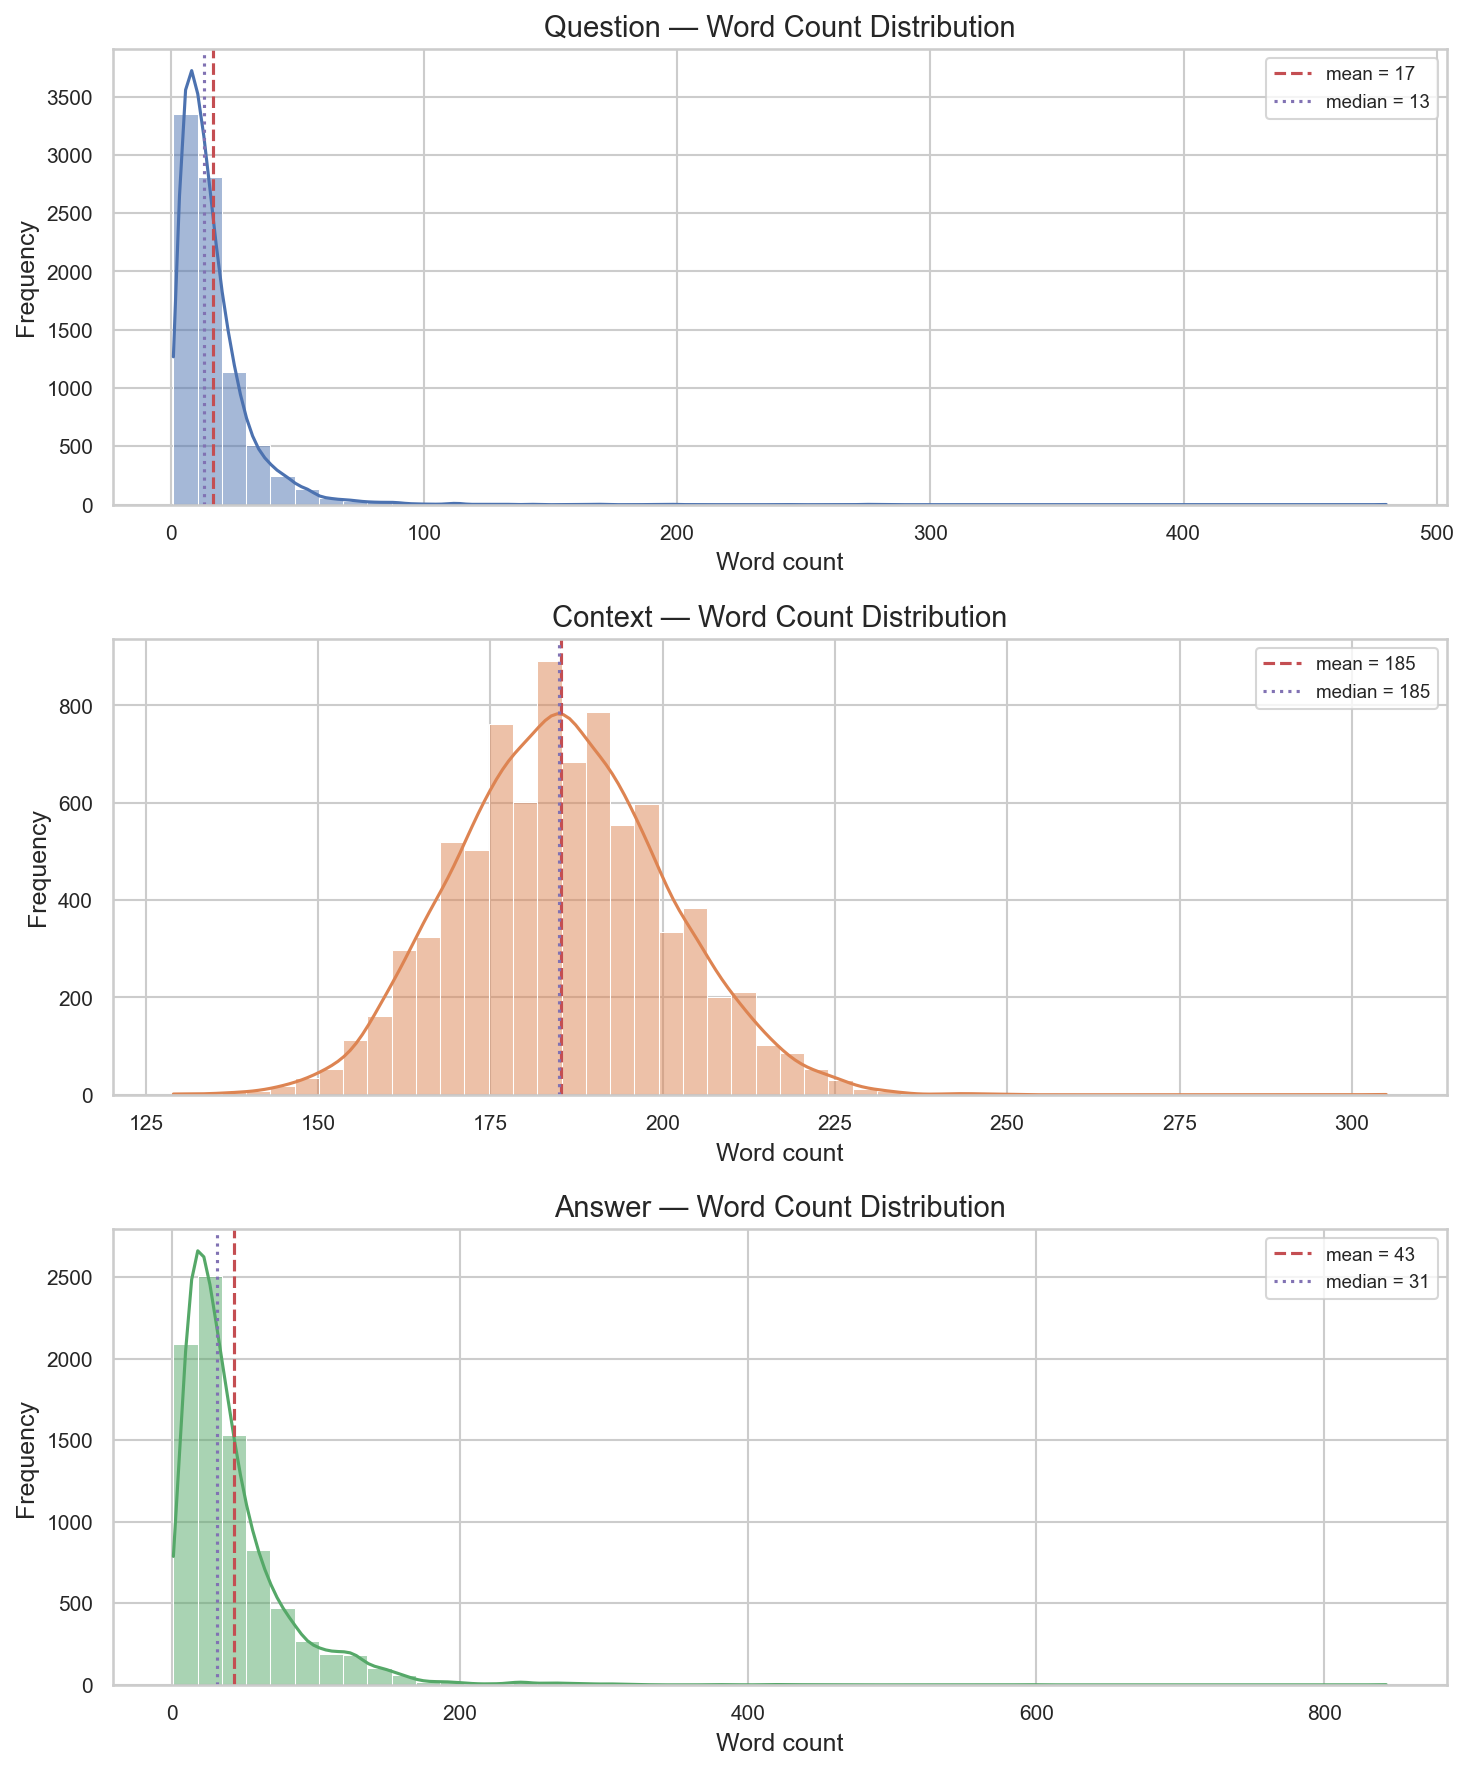

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, col in enumerate(TEXT_COLS):
    eda_utils.plot_length_distribution(
        df, col, length_type="word",
        title=f"{col.title()} — Word Count Distribution",
        ax=axes[i], color=eda_utils.PALETTE[i],
    )

fig.tight_layout()
plt.show()

d:\projects\ViRE\eda\eda_utils.py:240: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.boxplot(


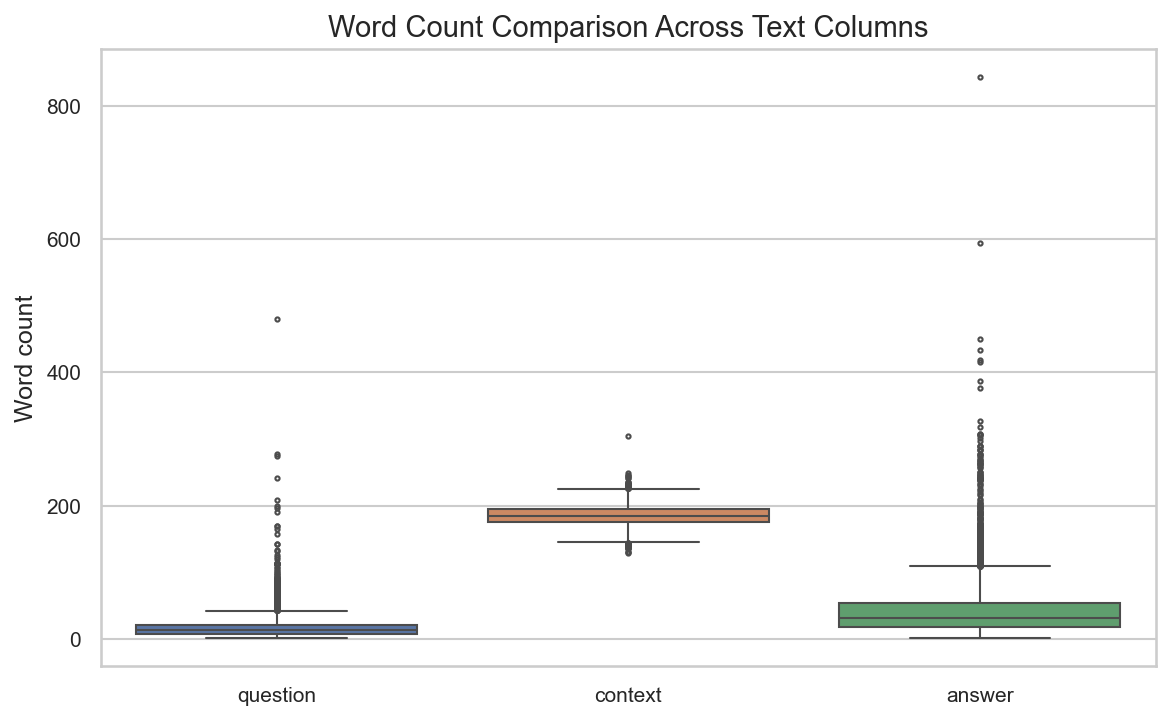

In [7]:
fig = eda_utils.plot_length_boxplots(
    df, TEXT_COLS, length_type="word",
    title="Word Count Comparison Across Text Columns",
)
plt.show()

d:\projects\ViRE\eda\eda_utils.py:240: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.boxplot(


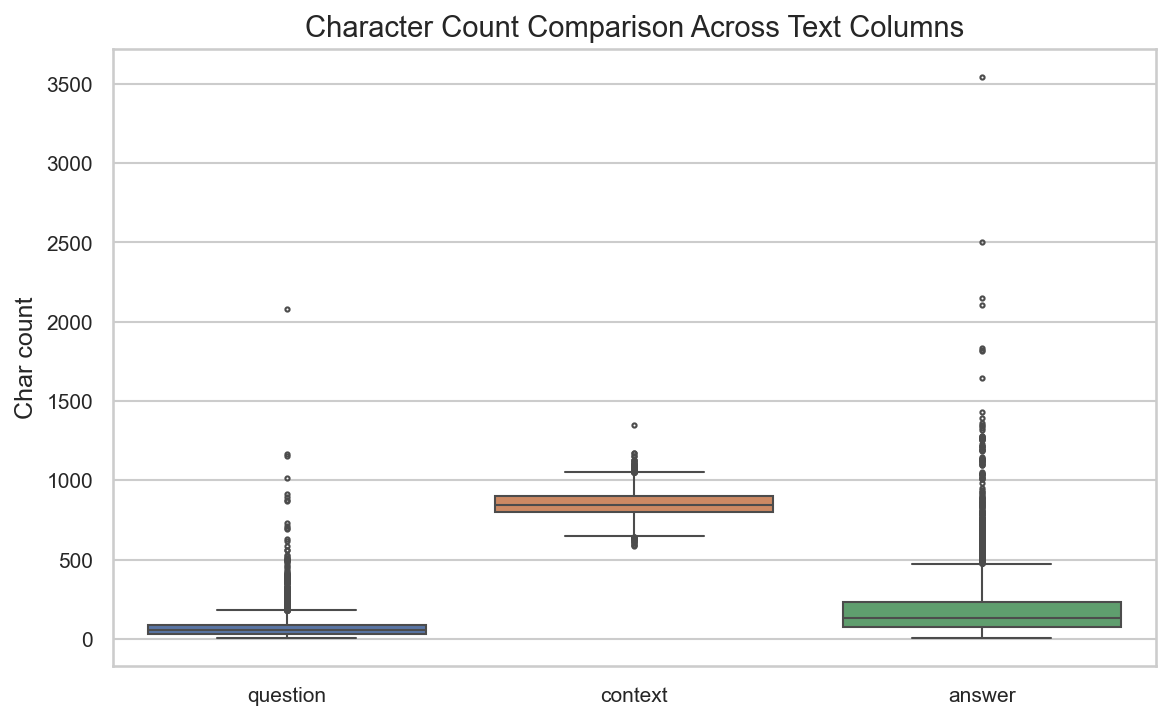

In [8]:
# Character-level distribution
fig = eda_utils.plot_length_boxplots(
    df, TEXT_COLS, length_type="char",
    title="Character Count Comparison Across Text Columns",
)
plt.show()

### Outlier Detection

Rows where context word count exceeds mean + 2σ:

In [9]:
import re

df["_context_words"] = df["context"].fillna("").apply(
    lambda x: len(re.split(r"\s+", x.strip()))
)

mean_w = df["_context_words"].mean()
std_w = df["_context_words"].std()
threshold = mean_w + 2 * std_w

outliers = df[df["_context_words"] > threshold]
print(f"Threshold (mean + 2σ): {threshold:.0f} words")
print(f"Outlier rows: {len(outliers):,} / {len(df):,} ({len(outliers)/len(df)*100:.1f}%)")

outliers[["qid", "question", "_context_words"]].head(10)

Threshold (mean + 2σ): 216 words
Outlier rows: 223 / 8,349 (2.7%)


,qid,question,_context_words
51,51,"Hi, mình cần tư vấn.",229
69,69,Tôi muốn dùng thử.,223
78,78,reload rồi vẫn ko đc. sửa đc chưa em. để bên a...,217
143,143,mình cần tìm hiểu để dùng dịch vụ bên abnj.,222
148,148,Phí khi đó tính sao e.,231
190,190,"gói này là vĩnh viễn e nhỉ, ko phải là 10 năm?...",219
308,308,"cái quan trọng nhất, m chạy qc web rất tốn.",227
353,353,Mỗi một sale lại có cách trả lời khách hàng kh...,222
354,354,kịch bản cũ em. giao diện kia là của kịch bản ...,222
421,421,có câu trả lời chưa ạ.,216


---
## 4. Word Frequency Analysis

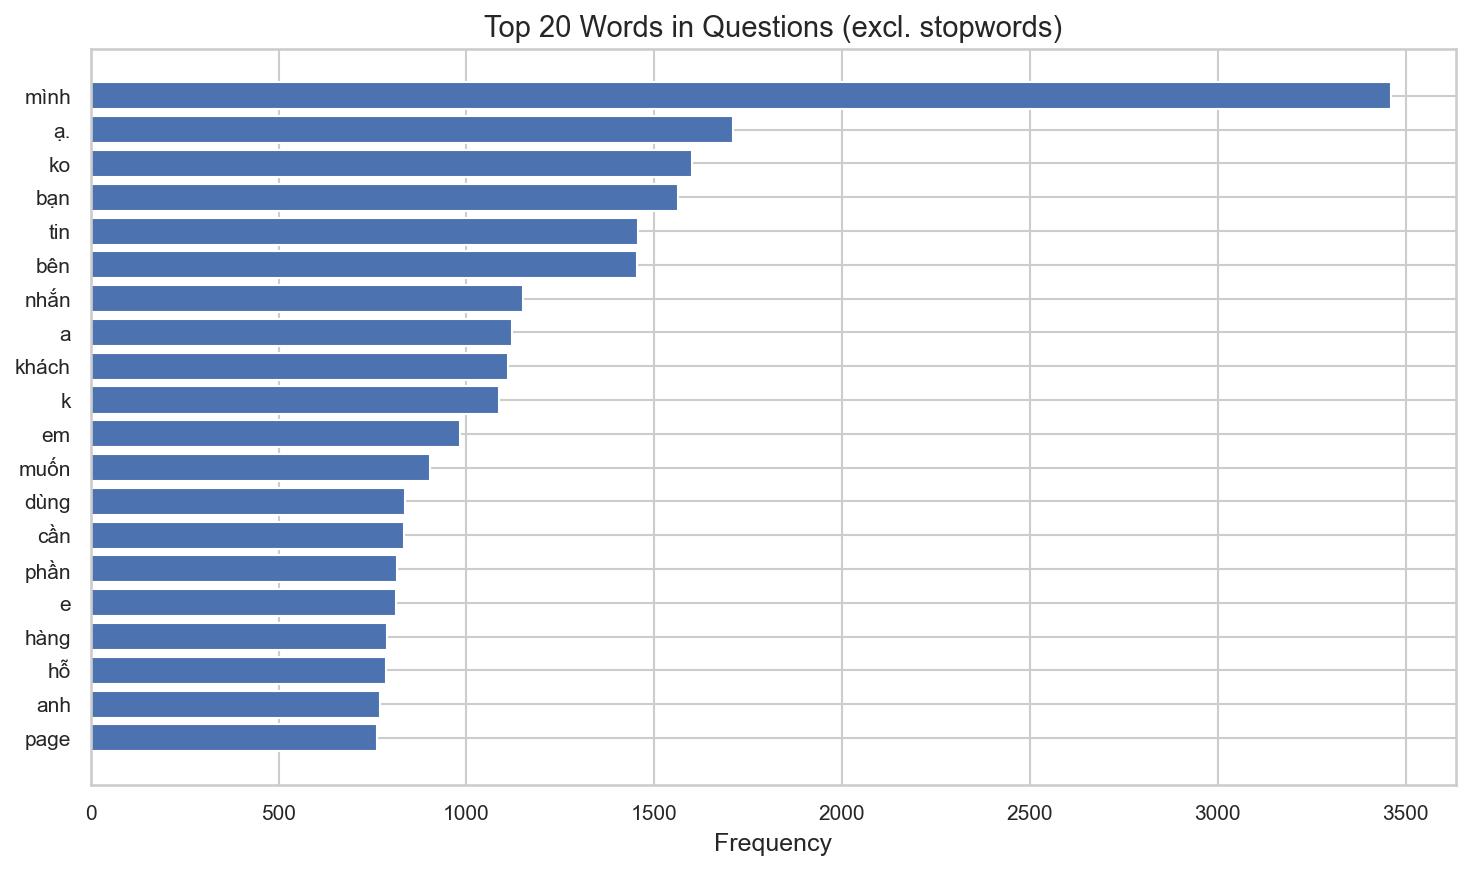

In [10]:
fig = eda_utils.plot_word_frequency(
    df, "question", top_n=20,
    title="Top 20 Words in Questions (excl. stopwords)",
)
plt.show()

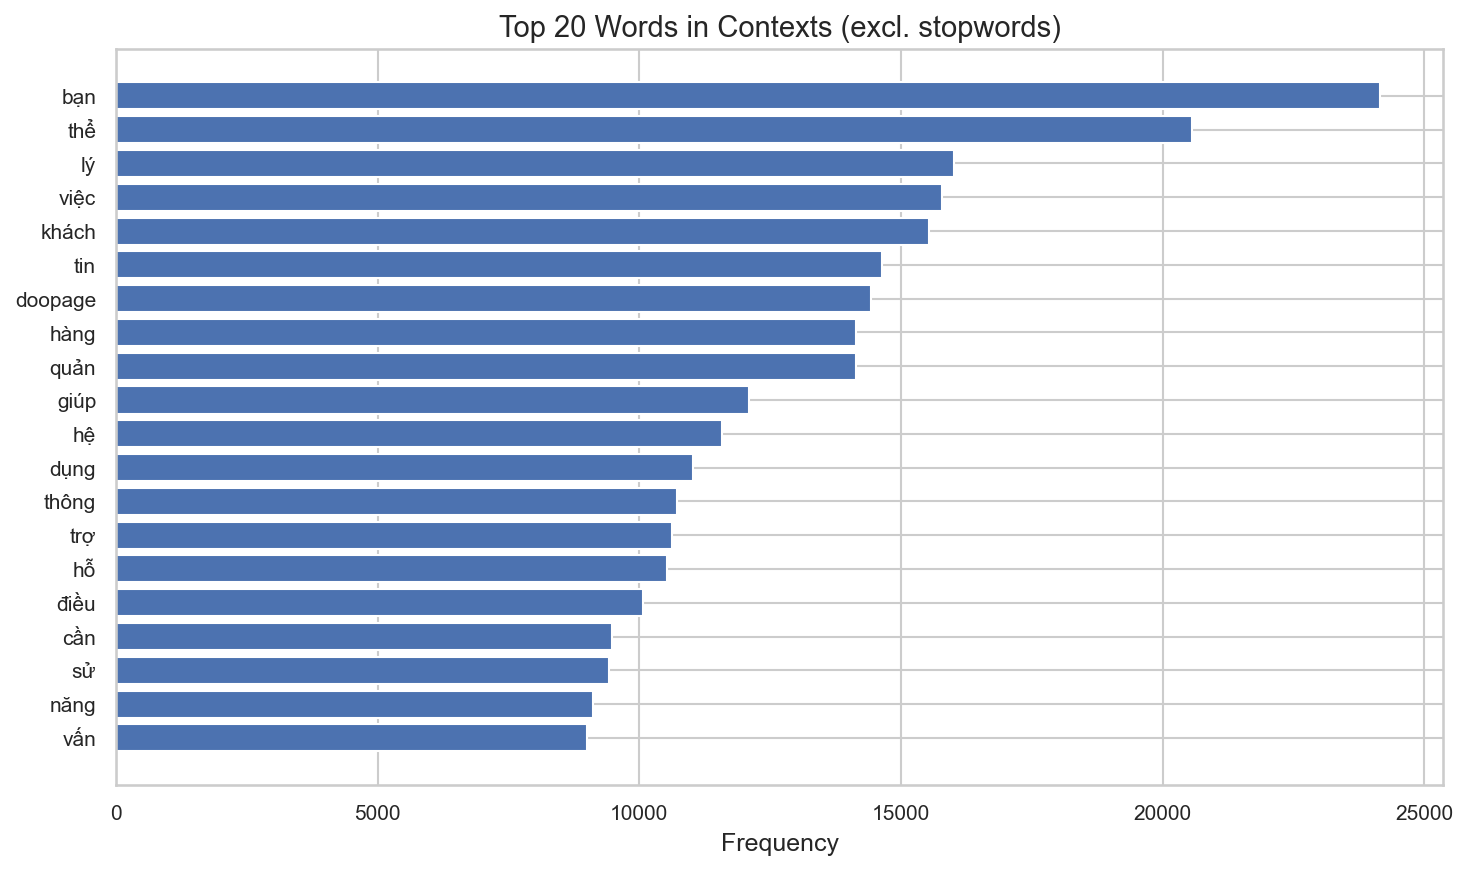

In [11]:
fig = eda_utils.plot_word_frequency(
    df, "context", top_n=20,
    title="Top 20 Words in Contexts (excl. stopwords)",
)
plt.show()

In [12]:
# Word cloud (optional — skipped if wordcloud is not installed)
try:
    from wordcloud import WordCloud

    all_questions = " ".join(df["question"].fillna(""))
    wc = WordCloud(
        width=1000, height=400,
        background_color="white",
        colormap="viridis",
        max_words=100,
    ).generate(all_questions)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Question Word Cloud")
    plt.show()
except ImportError:
    print("⚠️  `wordcloud` not installed — skipping. Install with: pip install wordcloud")

⚠️  `wordcloud` not installed — skipping. Install with: pip install wordcloud


---
## 5. Duplicate & Uniqueness Analysis

In [13]:
import pandas as pd

dup_records = [eda_utils.compute_duplicates(df, col) for col in TEXT_COLS]
dup_df = pd.DataFrame(dup_records)
dup_df.style.format({"unique_ratio": "{:.2%}"})

,column,total_rows,unique_values,duplicate_rows,unique_ratio
0,question,8349,7432,917,89.02%
1,context,8349,8349,0,100.00%
2,answer,8349,7732,617,92.61%


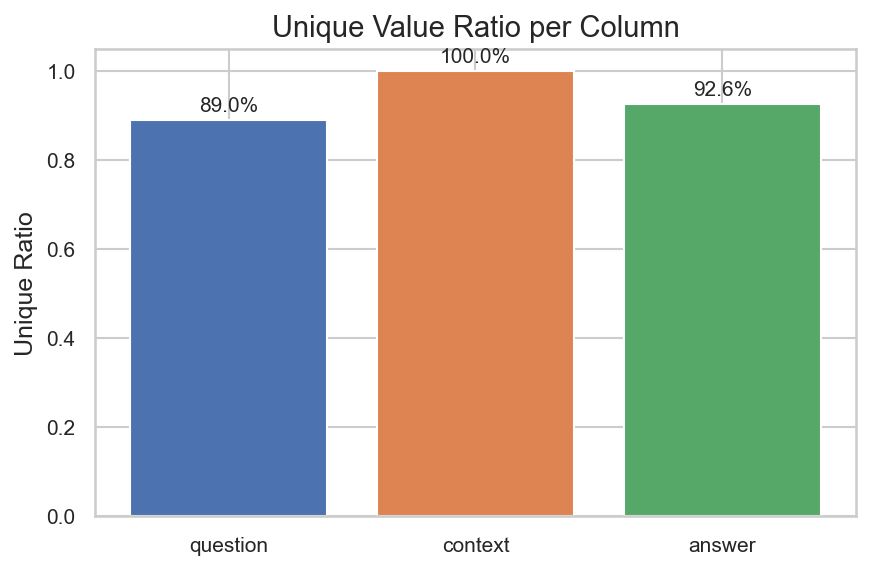

In [14]:
# Visualise unique ratios
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dup_df["column"], dup_df["unique_ratio"], color=eda_utils.PALETTE[:3], edgecolor="white")
ax.set_ylabel("Unique Ratio")
ax.set_title("Unique Value Ratio per Column")
ax.set_ylim(0, 1.05)
for i, v in enumerate(dup_df["unique_ratio"]):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=10)
fig.tight_layout()
plt.show()

---
## 6. Retrieval-Relevant Analysis

### 6.1 Vocabulary Statistics

In [15]:
vocab_records = [eda_utils.compute_vocabulary_stats(df, col) for col in TEXT_COLS]
vocab_df = pd.DataFrame(vocab_records)
vocab_df.style.format({
    "type_token_ratio": "{:.4f}",
    "hapax_ratio": "{:.4f}",
    "total_tokens": "{:,}",
    "vocab_size": "{:,}",
    "hapax_legomena": "{:,}",
})

,column,total_tokens,vocab_size,type_token_ratio,hapax_legomena,hapax_ratio
0,question,"139,719","5,476",0.0392,"2,018",0.3685
1,context,"1,546,607","5,261",0.0034,"1,785",0.3393
2,answer,"357,507","4,543",0.0127,"1,620",0.3566


### 6.2 Question–Context Lexical Overlap

In [16]:
overlaps = eda_utils.compute_overlap(df, "question", "context")

print(f"Mean Jaccard overlap  : {overlaps.mean():.4f}")
print(f"Median Jaccard overlap: {float(eda_utils.np.median(overlaps)):.4f}")
print(f"Std                   : {overlaps.std():.4f}")
print(f"Min                   : {overlaps.min():.4f}")
print(f"Max                   : {overlaps.max():.4f}")

Mean Jaccard overlap  : 0.0442
Median Jaccard overlap: 0.0357
Std                   : 0.0376
Min                   : 0.0000
Max                   : 0.3020


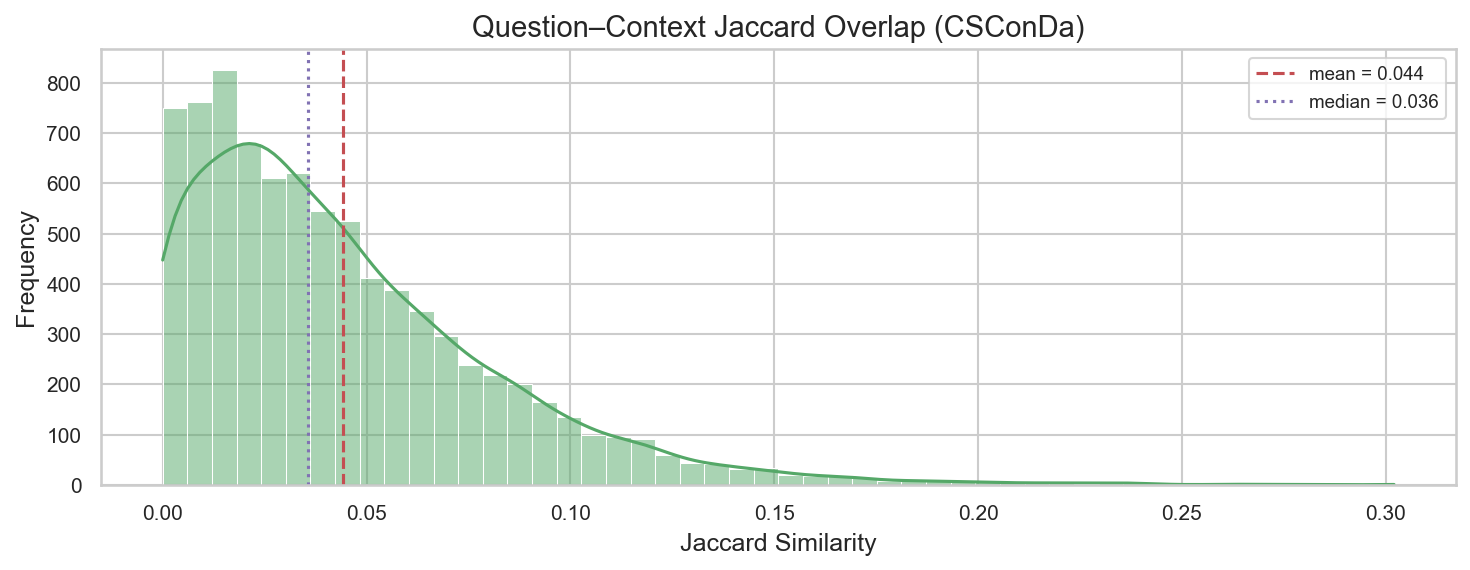

In [17]:
fig = eda_utils.plot_overlap_distribution(overlaps, title="Question–Context Jaccard Overlap (CSConDa)")
plt.show()

---
## 7. Summary

In [18]:
summary = eda_utils.summary_table(df, TEXT_COLS, dataset_name=DATASET_NAME)
summary

,dataset,column,total_rows,unique_values,unique_ratio,avg_words,median_words,max_words
0,CSConDa,question,8349,7432,0.8902,16.7,13.0,480
1,CSConDa,context,8349,8349,1.0000,185.2,185.0,305
2,CSConDa,answer,8349,7732,0.9261,42.8,31.0,843


### Key Findings

_(Fill in after reviewing the charts above)_

- **Dataset size:** ...
- **Text lengths:** ...
- **Duplicates:** ...
- **Vocabulary richness:** ...
- **Question–context overlap:** ...

In [ ]:
# Clean up temp columns
df.drop(columns=[c for c in df.columns if c.startswith("_")], inplace=True, errors="ignore")
print("✅ EDA complete for CSConDa.")